#  Визуализация табличных данных

**Цель**: построить ряд графиков, используемых при анализе данных с помощью средств языка программирования Python и библиотеки matplotlib

**Выполнил:** ст.группы 24ВВИ1 Будников А.С.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go

## Анализ

Помимо "стандартной" для работы библиотеки **pandas**, были также импортированы библиотекуи для визуализации даных: **seaborn** и **matplotlib**. 

In [2]:
df = pd.read_csv('data/covtype.csv') # default delimiter is ','\

In [3]:
renamed_cols = {
    'Elevation': 'Высота_над_уровнем_моря',
    'Aspect': 'Азимут_склона',
    'Slope': 'Уклон_склона',
    'Horizontal_Distance_To_Hydrology': 'Расстояние_до_воды_гориз',
    'Vertical_Distance_To_Hydrology': 'Расстояние_до_воды_верт',
    'Horizontal_Distance_To_Roadways': 'Расстояние_до_дорог',
    'Hillshade_9am': 'Освещённость_9_утра',
    'Hillshade_Noon': 'Освещённость_полдень',
    'Hillshade_3pm': 'Освещённость_3_дня',
    'Horizontal_Distance_To_Fire_Points': 'Расстояние_до_пожарных_точек',
    'Cover_Type': 'Тип_лесного_покрова',
}
for i in range(1, 5):
    renamed_cols[f'Wilderness_Area{i}'] = f'Зона_дикой_природы_{i}'

for i in range(1, 41):
    renamed_cols[f'Soil_Type{i}'] = f'Тип_почвы_{i}'

df = df.rename(columns=renamed_cols)

In [4]:
df.head()

,Высота_над_уровнем_моря,Азимут_склона,Уклон_склона,Расстояние_до_воды_гориз,Расстояние_до_воды_верт,Расстояние_до_дорог,Освещённость_9_утра,Освещённость_полдень,Освещённость_3_дня,Расстояние_до_пожарных_точек,...,Тип_почвы_32,Тип_почвы_33,Тип_почвы_34,Тип_почвы_35,Тип_почвы_36,Тип_почвы_37,Тип_почвы_38,Тип_почвы_39,Тип_почвы_40,Тип_лесного_покрова
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [5]:
print(f"Rows={df.shape[0]}", f"Columns={df.shape[1]}", sep='\t')

Rows=581012	Columns=55


## Анализ

В качестве датасета используется [Forest Cover Types](https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset/data).
Здесь содержатся данные о типах лесного покрова для территорий национального парка Рузвельта в Колорадо США. Каждая строка таблицы описывает один участок земли площадью 30×30 метров. Набор признаков включает информацию о типе дерева, степени затенения, расстоянии до близлежащих ориентиров (дорог и т. д.), типе почвы и местном рельефе. 

Всего в датасете 581 012 записей и 55 столбцов как показано выше. Для удобства чтения столбцы были переименованы

In [6]:
print(df.dtypes)

Высота_над_уровнем_моря         int64
Азимут_склона                   int64
Уклон_склона                    int64
Расстояние_до_воды_гориз        int64
Расстояние_до_воды_верт         int64
Расстояние_до_дорог             int64
Освещённость_9_утра             int64
Освещённость_полдень            int64
Освещённость_3_дня              int64
Расстояние_до_пожарных_точек    int64
Зона_дикой_природы_1            int64
Зона_дикой_природы_2            int64
Зона_дикой_природы_3            int64
Зона_дикой_природы_4            int64
Тип_почвы_1                     int64
Тип_почвы_2                     int64
Тип_почвы_3                     int64
Тип_почвы_4                     int64
Тип_почвы_5                     int64
Тип_почвы_6                     int64
Тип_почвы_7                     int64
Тип_почвы_8                     int64
Тип_почвы_9                     int64
Тип_почвы_10                    int64
Тип_почвы_11                    int64
Тип_почвы_12                    int64
Тип_почвы_13

In [7]:
print(df.nunique())
categorical_cols = [col for col in df.columns if df[col].nunique() == 2]
numeric_cols = [col for col in df.columns if df[col].nunique() > 2 and col != 'Тип_лесного_покрова']

Высота_над_уровнем_моря         1978
Азимут_склона                    361
Уклон_склона                      67
Расстояние_до_воды_гориз         551
Расстояние_до_воды_верт          700
Расстояние_до_дорог             5785
Освещённость_9_утра              207
Освещённость_полдень             185
Освещённость_3_дня               255
Расстояние_до_пожарных_точек    5827
Зона_дикой_природы_1               2
Зона_дикой_природы_2               2
Зона_дикой_природы_3               2
Зона_дикой_природы_4               2
Тип_почвы_1                        2
Тип_почвы_2                        2
Тип_почвы_3                        2
Тип_почвы_4                        2
Тип_почвы_5                        2
Тип_почвы_6                        2
Тип_почвы_7                        2
Тип_почвы_8                        2
Тип_почвы_9                        2
Тип_почвы_10                       2
Тип_почвы_11                       2
Тип_почвы_12                       2
Тип_почвы_13                       2
Т

## Анализ

Как видно из двух верхних пунктов таблица содержит данные типа ``int64``, поэтому выделить категориальные признаки здесь представляется возможным только путём отсечения столбцов по количеству уникальных значений. В данном случае пороговым числом было выбрано **2**. В данном датасете эвристика работает хорошо, потому что все категориальные признаки являются бинарными, и разрыв между группами очень велик.

Такой подход во многом оправдан: признаки с малым числом уникальных значений с высокой вероятностью являются бинарными или порядковыми категориями, тогда как признаки с большим числом уникальных значений - это непрерывные числовые величины. Важно также исключить из списка целевую переменную *Cover_Type*, имеющую 7 уникальных значений.

В результате разделения были получены две группы:

  - Числовые признаки (10 столбцов): Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points
  - Категоральные признаки (45 столбцов): Wilderness_Area1 ... Wilderness_Area4 (бинарные), Soil_Type1 … Soil_Type40 (бинарные)

Категоральные признаки в данном случае представлены как результат One-Hot Encoding, поэтому вместо 40 значений для единого Soil_Type, имеем 40 уникальных столбцов, которые по сути являются одним категориальным признаком, но на уровне представления в таблице будем воспринимать их как 40 бинарных столбцов.

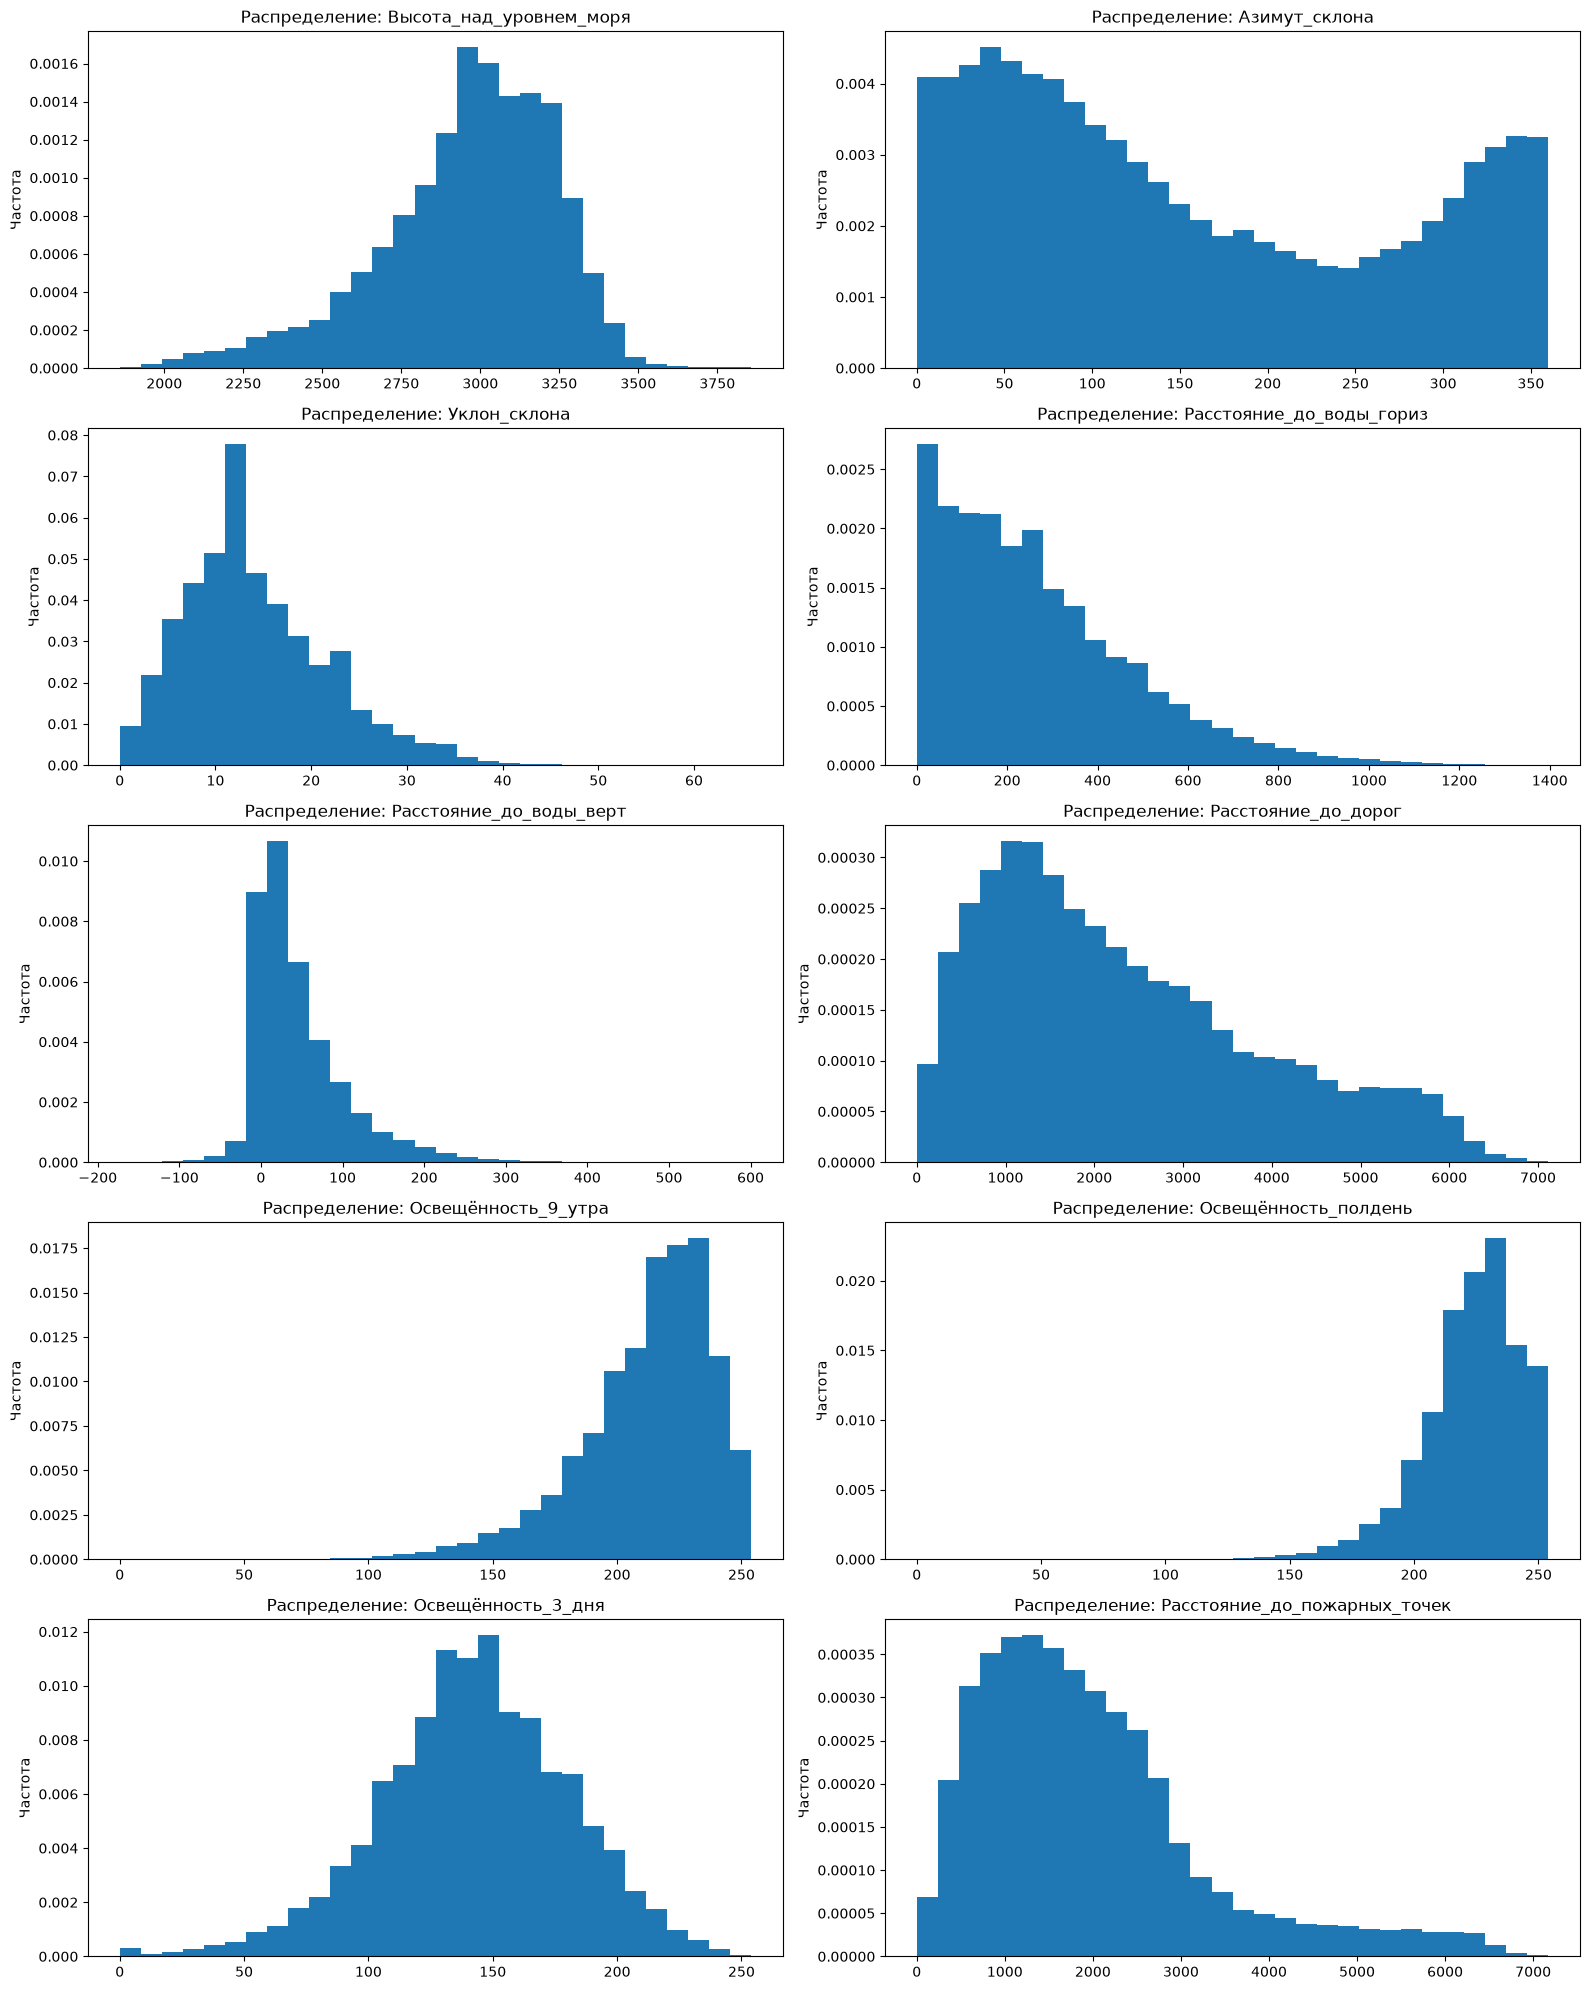

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, density=True)
    axes[i].set_title(f"Распределение: {col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

plt.tight_layout()
plt.show()

## Анализ

Построенные гистограммы показывают, что числовые признаки датасета имеют существенно разные формы распределения. Большинство из них не подчиняется нормальному закону.

* Высота над уровнем моря имеет несколько выраженных пиков. Это может говорить о том, что совокупность неоднородна: разные группы участков тяготеют к разным высотным диапазонам.
* Азимут склона принимает значения от 0 до 360. Видны отдельные всплески, которые могут соответствовать преобладающим направлениям склонов.
* Уклон склона имеет основную массу значений в области малых величин и длинный хвост в сторону больших значений. Это похоже на правостороннюю асимметрию.
* Признаки, связанные с расстояниями также скошены вправо. Большинство значений сосредоточено в небольшом диапазоне, но встречаются очень большие величины.
* Освещённость в 9 утра и освещённость в полдень наоборот смещены в сторону высоких значений: основная масса находится справа, а хвост уходит влево. Это похоже на левостороннюю асимметрию.
* Освещённость в 3 дня выглядит более симметричной, но всё равно имеет заметные хвосты.
  
Таким образом, на этапе гистограмм видно, что числовые признаки имеют разную форму распределения. Многие из них далеки от нормального закона.

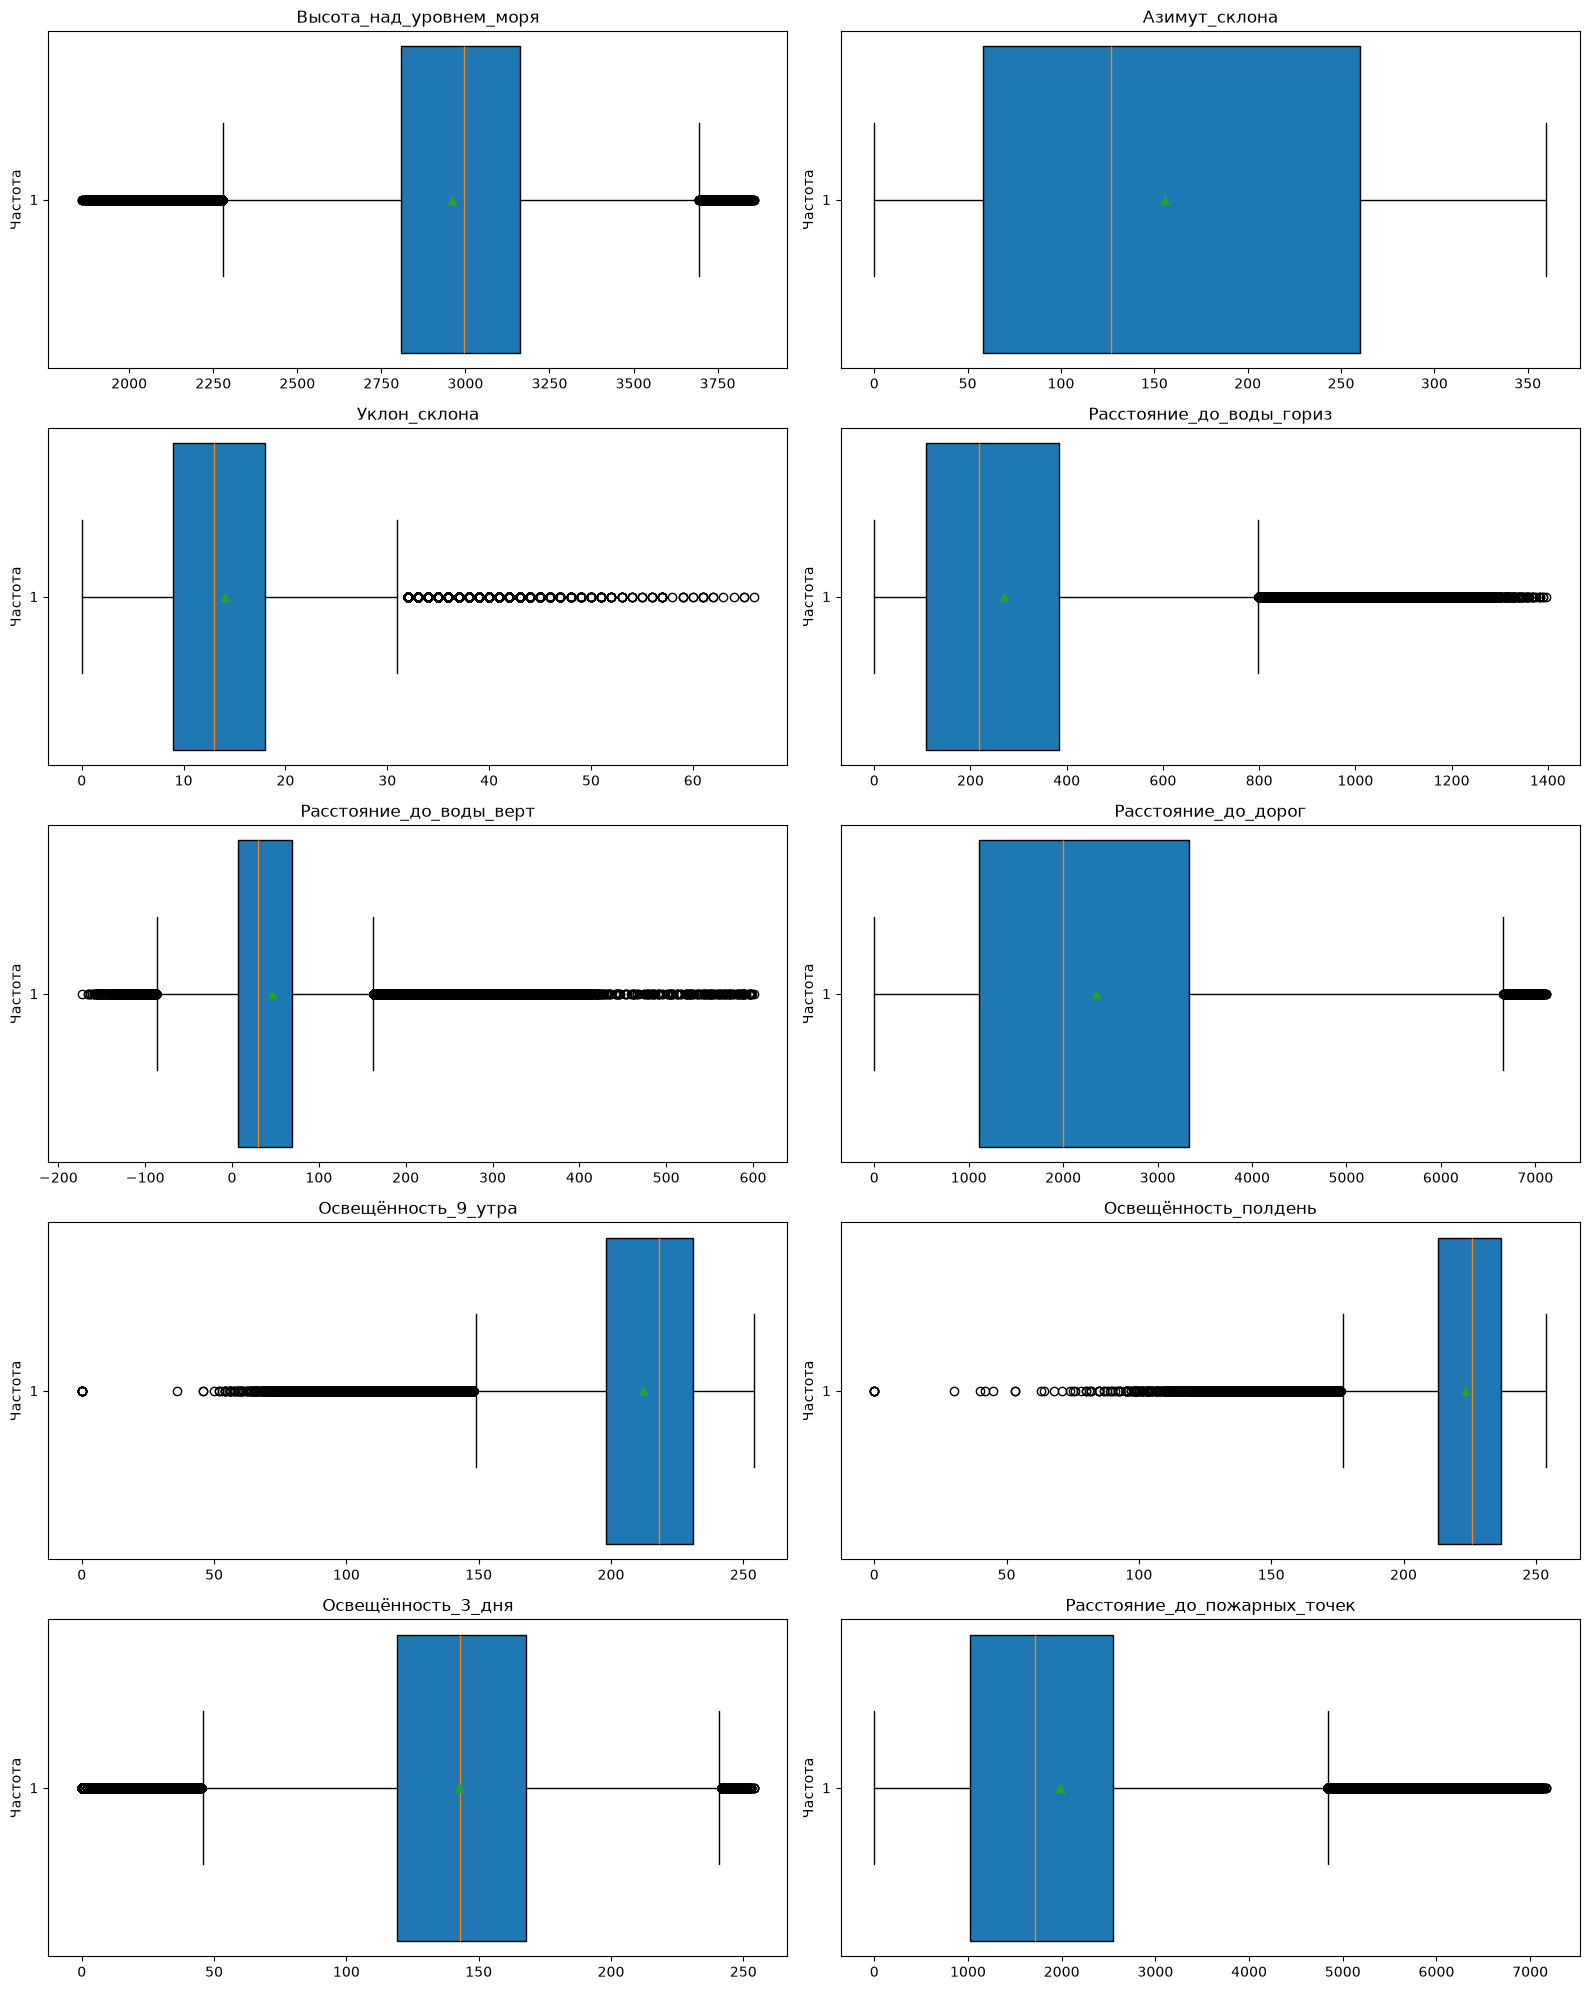

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], widths=1.5, patch_artist=True, showmeans=True, orientation='horizontal')
    
    axes[i].set_title(f"{col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

plt.tight_layout()
plt.show()

## Анализ

Ящики с усами позволяют оценить медиану, квартили, разброс и наличие выбросов. 

* Для признаков Расстояние до воды горизонтальное, Расстояние до воды вертикальное, Расстояние до дорог и Расстояние до пожарных точек виден длинный правый хвост и большое количество выбросов сверху. Это значит, что большинство участков расположены сравнительно недалеко от соответствующих объектов, но есть отдельные участки с очень большими расстояниями.
* Высота над уровнем моря имеет выбросы и снизу, и сверху. Это может быть не ошибкой измерений, а следствием природной неоднородности территории.
* Уклон склона имеет выбросы в верхней части диапазона. Крутые склоны встречаются редко.
* Освещённость утром и в полдень имеет выбросы преимущественно снизу. Большинство значений высокие, но есть отдельные сильно затенённые участки.
* Освещённость в 3 дня показывает выбросы по обе стороны, что говорит о неоднородности условий освещения во второй половине дня.

Наибольший межквартильный размах характерен для признаков, связанных с расстояниями. Наименьший — для уклона склона и освещённости в полдень.

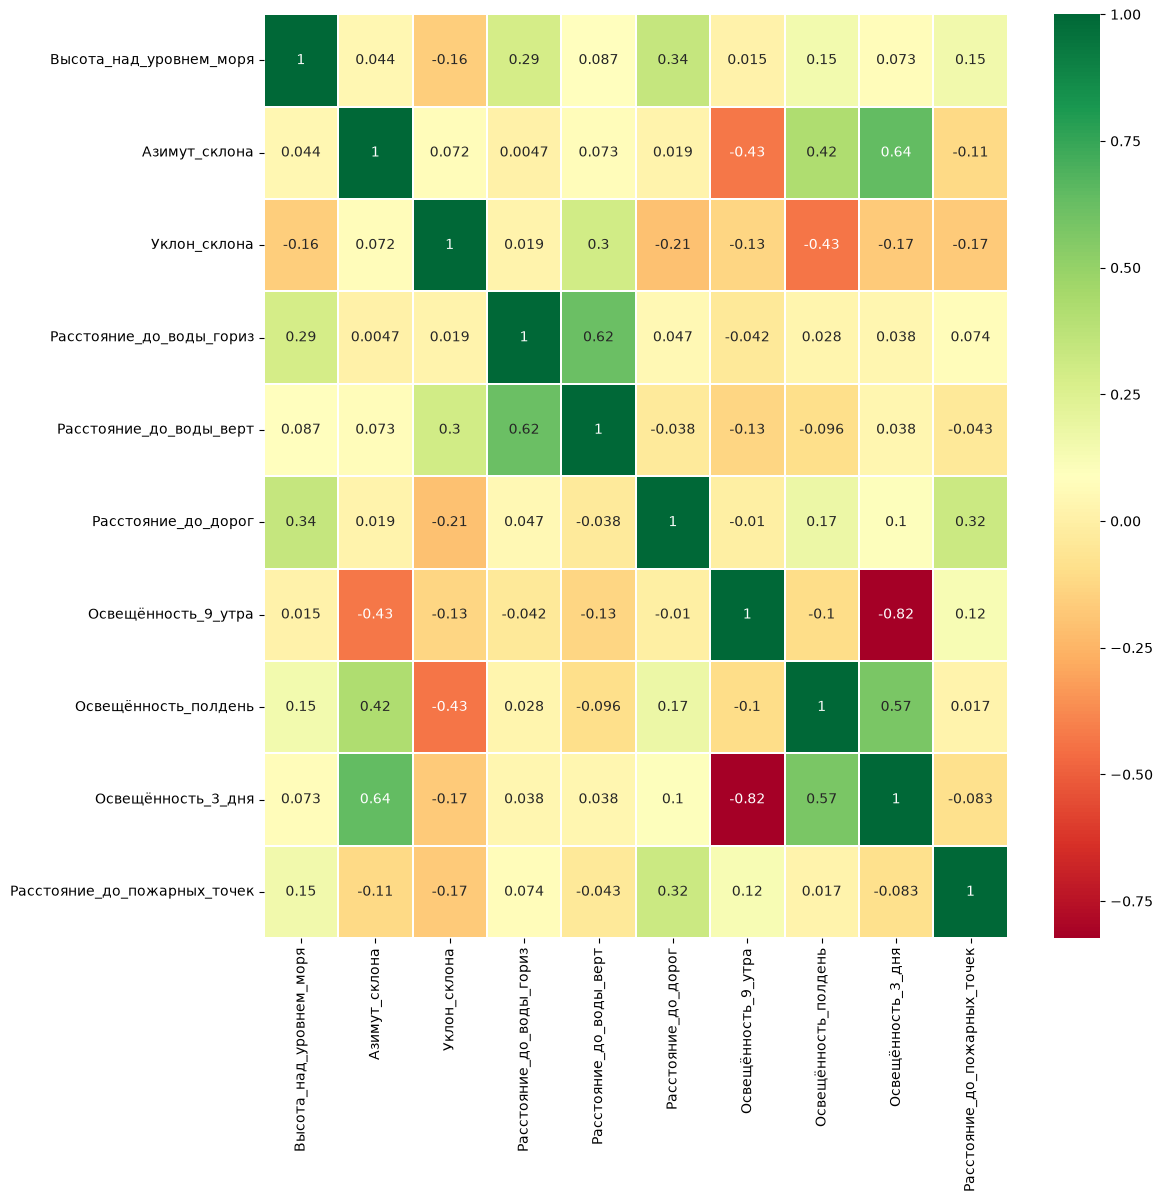

In [10]:
sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='RdYlGn', linewidths=0.2)
fig = plt.gcf()
fig.set_size_inches(12,12)
plt.show()

## Анализ

Согласно методичке, для порядковых переменных, а также в случаях, когда хотя бы одна из переменных не является нормально распределённой или содержит выбросы, следует использовать коэффициент Спирмана. 

### Коррелируемые показатели

Наиболее коррелируемыми показателями являются:

1. *Освещённость 9 тра* и *Освещённость 3дня* (-0.82) - самая сильная связь среди числовых признаков. Отрицательная корреляция объясняется тем, что участки, хорошо освещённые утром, как правило, хуже освещены во второй половине дня, и наоборот.
2. *Расстояние до воды гориз* и *Расстояние до воды верт* (0.62) - положительная связь. Оба признака описывают близость участка к воде: если участок расположен недалеко от водоёма в горизонтальном измерении, то и вертикальное расстояние обычно мало.
3. *Азимут_склона* и *Освещённость_3_дня* (0.64) — положительная связь. Ориентация склона напрямую определяет, насколько хорошо участок освещён во второй половине дня.
4. *`Освещённость полдень* и *Освещённость 3 дня* (0.57) - положительная связь. Здесь возможно роль играет близкое расположения на временном интервале дня. То есть при хорошей освещенности в полдень велика вероятность сохранения освещенности позднее, через три часа.

Также выделяется группа признаком с меньшим, но все же заметным коэффициентом корреляции:

1. *Азимут склона* и *Освещённость 9 утра* (-0.43) - отрицательная связь. Склоны, ориентированные на восток, лучше освещены утром.
2. *Азимут склона* и *Освещённость полдень* (0.42) - аналогично первому.
3. *Уклон_склона* и *Освещённость полдень* (-0.43) - отрицательная связь. Крутые склоны могут затеняться в полдень.
4. *Высота над ровнем моря* и *Расстояние до дорог* (0.34) - положительная связь. Участки на большей высоте обычно расположены дальше от дорог.
5. *Расстояние до дорог* и *Расстояние до пожарных точек* (0.32) — положительная связь. Возможно, что дороги и пожарные станции расположены рядом

Таким образом, все выявленные взаимосвязи имеют обоснование и связаны по большей части природными факторами

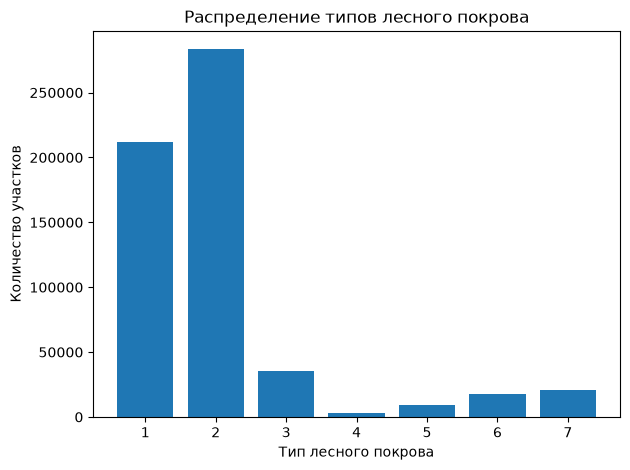

In [11]:
fig, ax = plt.subplots()
counts = df['Тип_лесного_покрова'].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values)
ax.set_title('Распределение типов лесного покрова')
ax.set_xlabel('Тип лесного покрова')
ax.set_ylabel('Количество участков')
plt.tight_layout()
plt.show()

## Анализ

Столбчатая диаграмма показывает распределение целевой переменной — типа лесного покрова.

* Типы 1 и 2 являются доминирующими: вместе они покрывают большую часть всех наблюдений.
* Типы 6 и 7 встречаются заметно реже.
* Тип 3 представлен умеренно.
* Тип 5 встречается редко.
* Тип 4 — самый редкий, его доля очень мала.

Такой дисбаланс является важной особенностью датасета. Если строить модель классификации без учёта этого факта, она может сместиться в сторону предсказания наиболее частых классов.

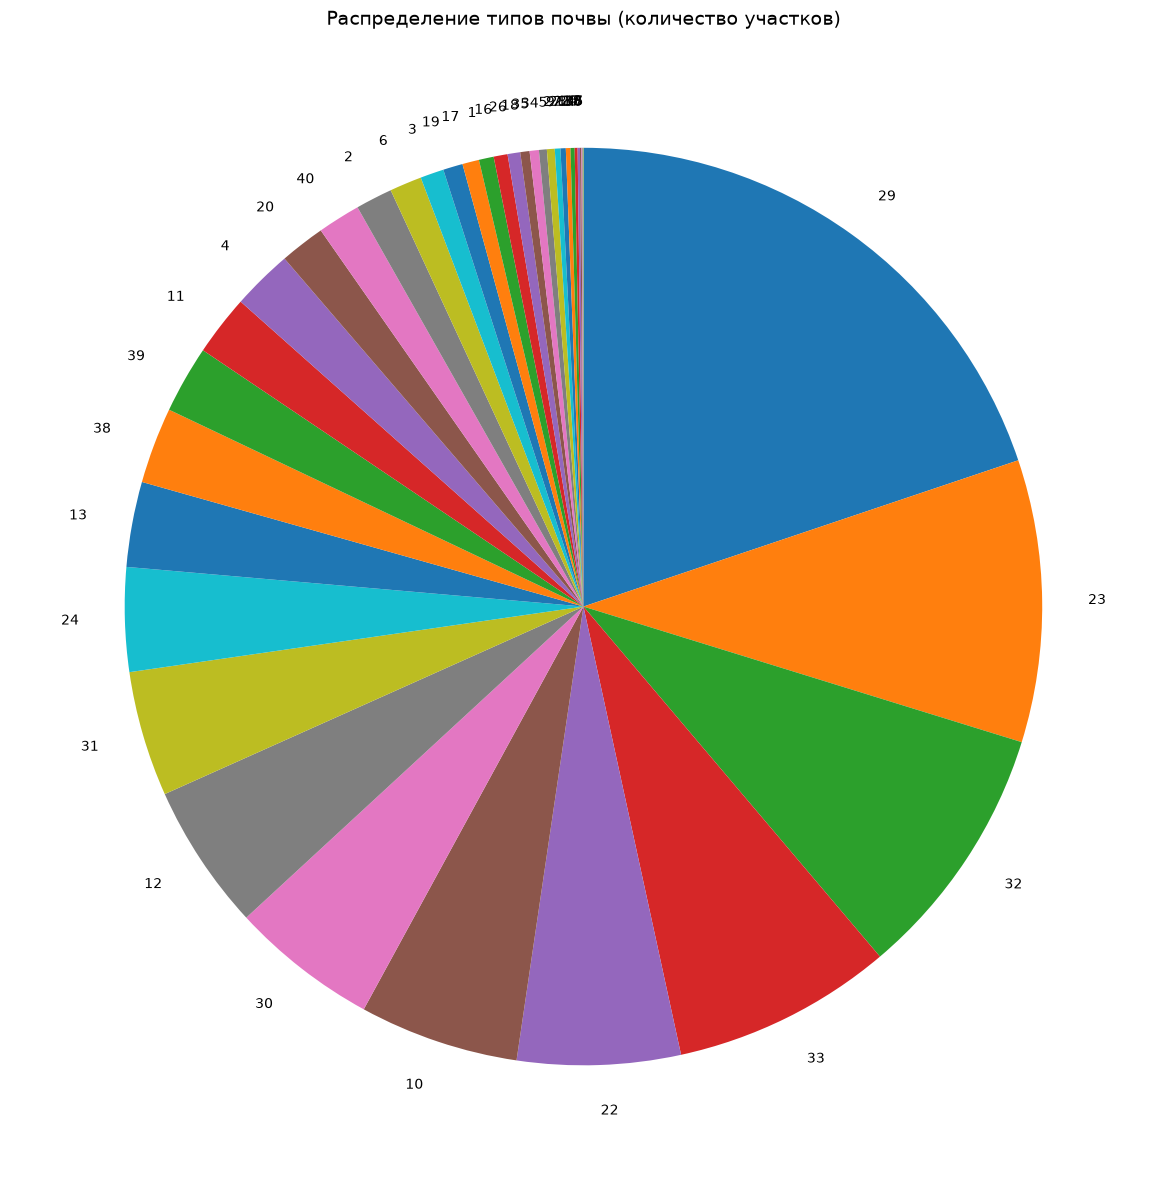

In [23]:
soil_cols = [c for c in df.columns if c.startswith('Тип_почвы_')]
soil_counts = df[soil_cols].sum().sort_values(ascending=False)
labels = [c.replace('Тип_почвы_', '') for c in soil_counts.index]
fig, ax = plt.subplots(figsize=(12, 12))
_, _ = ax.pie(
    soil_counts.values,
    labels=labels,  
    startangle=90,
    counterclock=False
)
ax.set_title('Распределение типов почвы (количество участков)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
soil_counts = df[soil_cols].sum().sort_values(ascending=False)
soil_counts = soil_counts[soil_counts > 0]
labels = [c.replace('Тип_почвы_', 'Т') for c in soil_counts.index]

fig = go.Figure(go.Scatter(x=labels, y=soil_counts.values))
fig.update_layout(
    title='Типы почвы, отсортированные по частоте',
    xaxis_title='Тип почвы', yaxis_title='Количество участков',
    width=1200, height=500,
)
fig.show(renderer='iframe')

## Анализ

Для анализа категориального признака «Тип почвы» были построены две визуализации: круговая диаграмма и интерактивный линейный график с сортировкой по частоте.

Круговая диаграмма позволяет увидеть доли категорий, но из-за большого числа типов диаграмма оказывается перегруженной. Мелкие сектора почти неразличимы, подписи накладываются, и оценить реальное соотношение частот становится сложно. Тем не менее даже на таком графике заметно, что один тип почвы доминирует, а многие другие представлены очень малыми долями. 

Благодаря интерактивному графику можно более ясно увидеть структуру распределения:

* Наиболее распространённым является тип почвы 29. За ним следуют типы 23, 32, 33, 22, 10, 30 и 12.
* При этом многие типы встречаются крайне редко: например, типы 15, 7, 36, 8, 37, 25 имеют менее 500 наблюдений, а тип 15 — всего несколько случаев.

Таким образом, обе визуализации подтверждают: распределение типов почвы сильно неравномерно. Круговая диаграмма полезна для общего впечатления о наличии доминирующих категорий, но для анализа конкретных частот удобнее интерактивный линейный график.